# CompCars Showroom: 431 Benchmark Models - Result & Performance Analysis

This notebook evaluates the performance of the trained **EfficientNetB0 (Cropped Bounding Boxes)** model across all **431 benchmark car models** from the CompCars Web-Nature (Showroom) dataset.

All underlying data pipelines, metrics aggregations, and plotting logic are modularly encapsulated in **`functions.py`** (loaded via `from functions import *`).

### Analysis Modules:
1. **Load Functions & Setup**: Imports and function definitions (`from functions import *`).
2. **Model & Benchmark Metadata**: Load trained model and metadata.
3. **Test Dataset Preparation**: Build test dataframe with bounding boxes and viewpoints.
4. **Class-wise Accuracy Computation**: Compute or load accuracy across all 431 models (`compcars_showroom_classwise_accuracy.csv`).
5. **Global Statistics & Performance Tiers**: Macro mean, median, standard deviation, and tier breakdown (<25% to >90%).
6. **Visualizations**: Full accuracy spectrum bar plot (sorted #1 to #431) and distribution histogram.
7. **Top 10 & Bottom 10 Analysis**: High-performing car models vs. lowest-performing models.
8. **Make-wise Accuracy Across All 75 Brands**: Complete 75-brand ranking table and two-panel bar chart.
9. **CompCars CCTV (Surveillance) Overlap**: Analysis of showroom models shared with CCTV surveillance classes.
10. **Interactive Image Inspection with Bounding Boxes**: View all images of any car model with official bounding box overlays.


### 1. Load Analysis Functions & Setup
Import all modular data pipelines, aggregation tools, and plotting functions from `functions.py`.


In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

I0000 00:00:1788928023.059001 1068842 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788928023.088065 1068842 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788928023.836324 1068842 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Load all functions and classes from functions.py
from functions import *
print("Loaded analysis and visualization functions from functions.py successfully.")


Loaded analysis and visualization functions from functions.py successfully.


### 2. Load Trained Showroom Model & Class Metadata (431 Benchmark Models)


In [3]:
model, meta_dict = load_model_and_metadata(
    model_path="showroom_bbox_b0_finetuned.keras",
    data_dir="../../../../dataset_Source"
)
DATA_DIR = meta_dict["data_dir"]
IMG_DIR = meta_dict["img_dir"]
LABEL_DIR = meta_dict["label_dir"]
SPLIT_DIR = meta_dict["split_dir"]
NUM_CLASSES = meta_dict["num_classes"]


Loading model from 'showroom_bbox_b0_finetuned.keras'...


I0000 00:00:1788928024.614505 1068842 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20392 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Loaded model and metadata successfully. Total benchmark classes: 431


### 3. Test Dataset Preparation & Bounding Box Data Generator


In [4]:
test_df = prepare_test_dataframe(DATA_DIR, meta_dict["test_lines"], meta_dict)


Constructed test dataframe with 14939 samples across 431 classes.


### 4. Class-wise Accuracy Computation Across All 431 Models
Load precomputed accuracy metrics from `compcars_showroom_classwise_accuracy.csv` (or execute model inference dynamically).


In [5]:
class_acc_df = compute_classwise_accuracy(
    model=model,
    test_df=test_df,
    meta_dict=meta_dict,
    csv_path="compcars_showroom_classwise_accuracy.csv",
    force_recompute=False
)
display(class_acc_df.head(10))


Loading precomputed class-wise accuracy metrics from 'compcars_showroom_classwise_accuracy.csv'...


,class_index,make_id,make_name,model_id,class_name,folder_path,sample_image,total_samples,correct_samples,accuracy_pct
0,0,78,Audi,1,Audi A3 hatchback,../../../../dataset_Source/image/78/1,../../../../dataset_Source/image/78/1/2014/3ac...,69,63,91.30
1,1,78,Audi,2,Audi A4L,../../../../dataset_Source/image/78/2,../../../../dataset_Source/image/78/2/2013/9c3...,82,68,82.93
2,2,78,Audi,3,Audi A6L,../../../../dataset_Source/image/78/3,../../../../dataset_Source/image/78/3/2010/f08...,66,56,84.85
3,3,78,Audi,4,Audi Q3,../../../../dataset_Source/image/78/4,../../../../dataset_Source/image/78/4/2012/46b...,29,26,89.66
4,4,78,Audi,5,Audi Q5,../../../../dataset_Source/image/78/5,../../../../dataset_Source/image/78/5/2011/b11...,75,70,93.33
5,5,78,Audi,11,Audi A3 sedan,../../../../dataset_Source/image/78/11,../../../../dataset_Source/image/78/11/2014/fb...,26,23,88.46
6,6,78,Audi,19,Audi A1,../../../../dataset_Source/image/78/19,../../../../dataset_Source/image/78/19/2012/bb...,41,34,82.93
7,7,78,Audi,21,Audi A4 estate,../../../../dataset_Source/image/78/21,../../../../dataset_Source/image/78/21/2014/fa...,18,15,83.33
8,8,78,Audi,22,Audi A5 convertible,../../../../dataset_Source/image/78/22,../../../../dataset_Source/image/78/22/2010/f9...,45,36,80.00
9,9,78,Audi,23,Audi A5 coupe,../../../../dataset_Source/image/78/23,../../../../dataset_Source/image/78/23/2012/c6...,54,47,87.04


### 5. Global Performance Statistics & Performance Tier Breakdown


In [6]:
global_stats, tier_summary = get_global_statistics(class_acc_df)
display(tier_summary)



================ Global Accuracy Metrics (431 Models) ================
  Macro Mean Accuracy   : 83.04%
  Median Accuracy       : 85.71%
  Standard Deviation    : 12.90%
  Min Accuracy          : 20.00%
  Max Accuracy          : 100.00%



,Performance Tier,Number of Models,Share of All Models
0,< 25% (Critical),1,0.2%
1,25% - 50% (Poor),12,2.8%
2,50% - 75% (Fair),94,21.8%
3,75% - 90% (Good),172,39.9%
4,90% - 100% (Excellent),152,35.3%


### 6. Visualizations Across All 431 Models
- **Sorted Accuracy Bar Plot**: Full spectrum of all 431 classes sorted from lowest to highest accuracy.
- **Threshold Highlights**: Prominent reference lines at **50%**, **70%**, and **90%**, with color-coded performance tiers.
- **Accuracy Distribution**: Tier-aligned histogram showing model density across test accuracy percentages.


/home/researchadmin/Econ/repo-clone/stanford-cars-model/code/current/functions.py:384: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


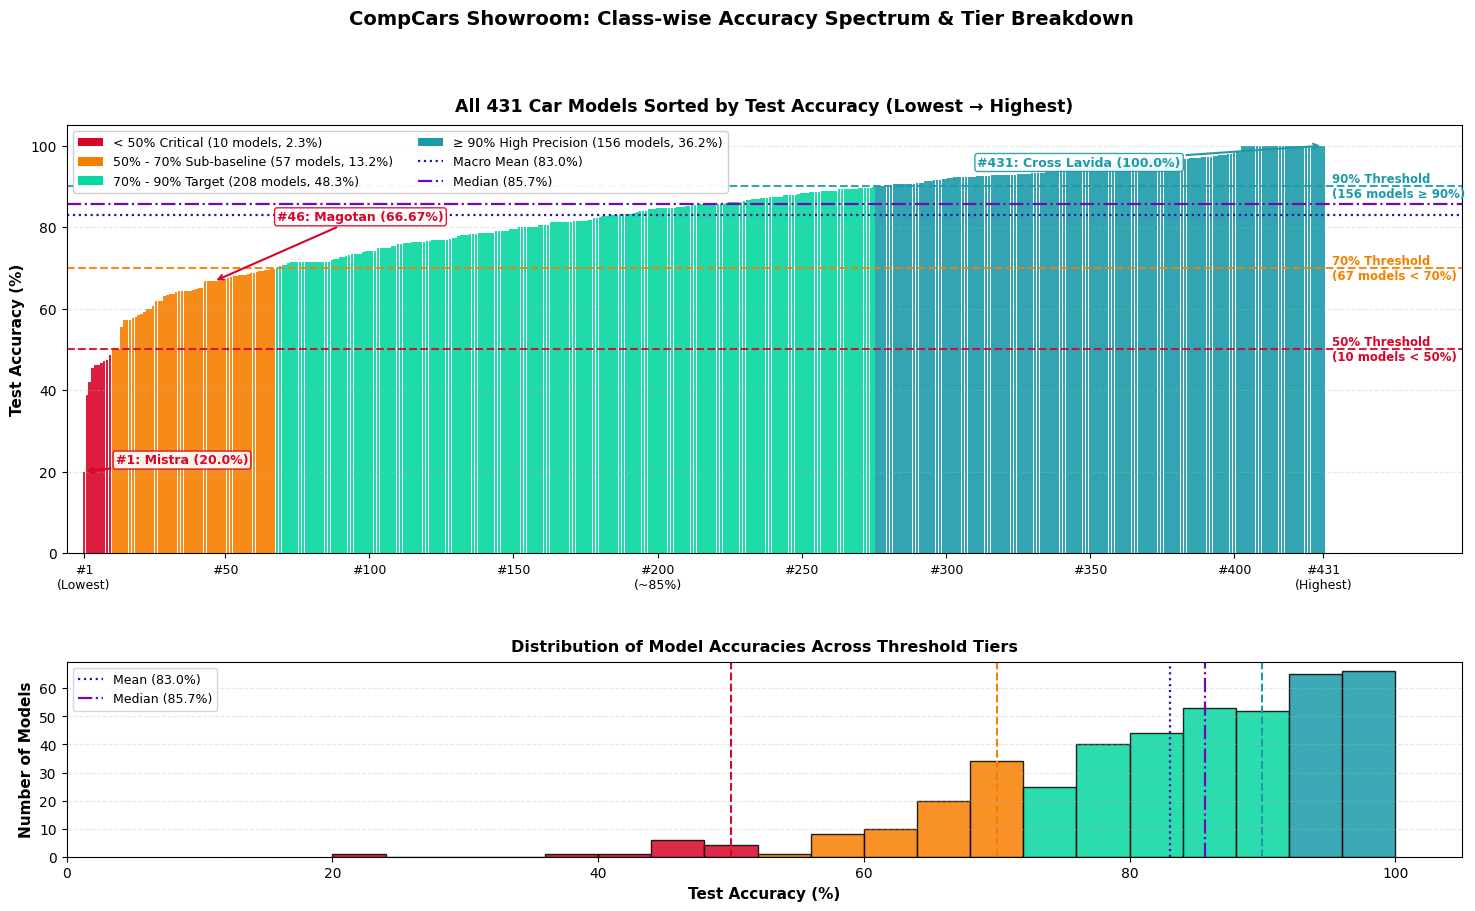

In [7]:
# Plot sorted class accuracy spectrum and distribution histogram
plot_accuracy_spectrum(class_acc_df)


### 7. Top 10 Highest & Bottom 10 Lowest Accuracy Models


In [8]:
top_10, bottom_10 = get_top_and_bottom_models(class_acc_df, n=10)

print("================ Top 10 Highest Accuracy Models ================")
display(top_10)

print("\n================ Bottom 10 Lowest Accuracy Models ================")
display(bottom_10)


================ Top 10 Highest Accuracy Models ================


,model_id,make_id,make_name,class_name,accuracy_pct,correct_samples,total_samples,folder_path
429,1984,37,Zxauto,Grandtiger TUV,100.0,22,22,../../../../dataset_Source/image/37/1984
426,1961,38,Zhonghua,Zhonghua H230,100.0,11,11,../../../../dataset_Source/image/38/1961
373,1790,149,Suzuki,Alto,100.0,48,48,../../../../dataset_Source/image/149/1790
383,1829,14,MG,MG5,100.0,26,26,../../../../dataset_Source/image/14/1829
378,1796,149,Suzuki,Yuyan,100.0,48,48,../../../../dataset_Source/image/149/1796
344,1637,162,MAZDA,Axela sedan,100.0,14,14,../../../../dataset_Source/image/162/1637
349,1657,75,Chrey,Chrey A3 sedan,100.0,17,17,../../../../dataset_Source/image/75/1657
353,1665,75,Chrey,Chrey X1,100.0,22,22,../../../../dataset_Source/image/75/1665
341,1634,162,MAZDA,Mazda 3 Xingcheng hatchback,100.0,16,16,../../../../dataset_Source/image/162/1634
50,188,54,Buck,Buick GL8 Luxury Business,100.0,37,37,../../../../dataset_Source/image/54/188



================ Bottom 10 Lowest Accuracy Models ================


,model_id,make_id,make_name,class_name,accuracy_pct,correct_samples,total_samples,folder_path
223,959,118,Hyundai,Mistra,20.00,2,10,../../../../dataset_Source/image/118/959
427,1962,84,Brabus,Brabus S Class,38.89,7,18,../../../../dataset_Source/image/84/1962
125,439,73,Volkswagen,Gran Lavida,42.11,8,19,../../../../dataset_Source/image/73/439
339,1632,162,MAZDA,Mazda 2 sedan,45.45,5,11,../../../../dataset_Source/image/162/1632
113,406,152,Changan,Yuexiang V3,46.15,6,13,../../../../dataset_Source/image/152/406
269,1253,158,Citroen,Elysee,46.15,6,13,../../../../dataset_Source/image/158/1253
123,436,73,Volkswagen,Polo sedan,46.67,7,15,../../../../dataset_Source/image/73/436
230,976,118,Hyundai,Rohens,47.06,8,17,../../../../dataset_Source/image/118/976
306,1494,69,Geely,Ziyoujian,47.37,9,19,../../../../dataset_Source/image/69/1494
277,1322,39,Toyota,Crown,48.57,17,35,../../../../dataset_Source/image/39/1322


### 8. Make-wise (Brand-level) Accuracy & Performance Analysis: All 75 Brands
Aggregate classification metrics across all **75 car manufacturers/brands** in the benchmark test set:
- Full 75-brand ranking table with model counts, test sample volumes, and best/worst models.
- Performance tier distribution across all 75 brands (<50% Critical, 50-70% Sub-baseline, 70-90% Target, ≥90% High Precision).
- Complete two-panel visual ranking displaying **every single brand** with threshold benchmarks (50%, 70%, 90%).
- Interactive brand model inspector (`view_make_summary`).


Saved full metrics for all 75 brands to 'compcars_showroom_makewise_accuracy.csv'
================ Performance Tier Distribution Across All 75 Brands ================


,Tier,Brand Count,Share,Example Brands
0,< 50% (Critical),1,1.3%,Brabus
1,50% - 70% (Sub-baseline),5,6.7%,"Jonway, Wealeak, SAAB, GAC, Opel"
2,70% - 90% (Target Range),45,60.0%,"Zoyte, Everus, Subaru, Venucia, Hyundai"
3,≥ 90% (High Precision),24,32.0%,"Karry, Volvo, Infiniti, MINI, Buck"



================ Complete Ranking Table: All 75 Brands (Sorted Lowest → Highest) ================


,rank,make_id,make_name,num_models,total_samples,correct_samples,accuracy_pct,macro_acc_pct,best_model,worst_model
0,1,84,Brabus,1,18,7,38.89,38.89,Brabus S Class (38.89%),Brabus S Class (38.89%)
1,2,106,Jonway,1,9,5,55.56,55.56,Yongyuan A380 (55.56%),Yongyuan A380 (55.56%)
2,3,80,Wealeak,1,10,6,60.00,60.00,WeaLink X5 (60.0%),WeaLink X5 (60.0%)
3,4,128,SAAB,1,14,9,64.29,64.29,SAAB D70 (64.29%),SAAB D70 (64.29%)
4,5,88,GAC,1,9,6,66.67,66.67,Saboo GX5 (66.67%),Saboo GX5 (66.67%)
5,6,103,Opel,3,80,54,67.50,71.12,Zafira (84.62%),GTC hatchback (60.0%)
6,7,45,Zoyte,1,17,12,70.59,70.59,Zotye 5008 (70.59%),Zotye 5008 (70.59%)
7,8,119,Everus,1,21,15,71.43,71.43,Linian S1 (71.43%),Linian S1 (71.43%)
8,9,94,Subaru,2,55,40,72.73,72.34,Impreza sedan (76.67%),Impreza hatchback (68.0%)
9,10,70,Venucia,2,44,32,72.73,73.47,Venucia R50 (78.95%),Venucia D50 (68.0%)


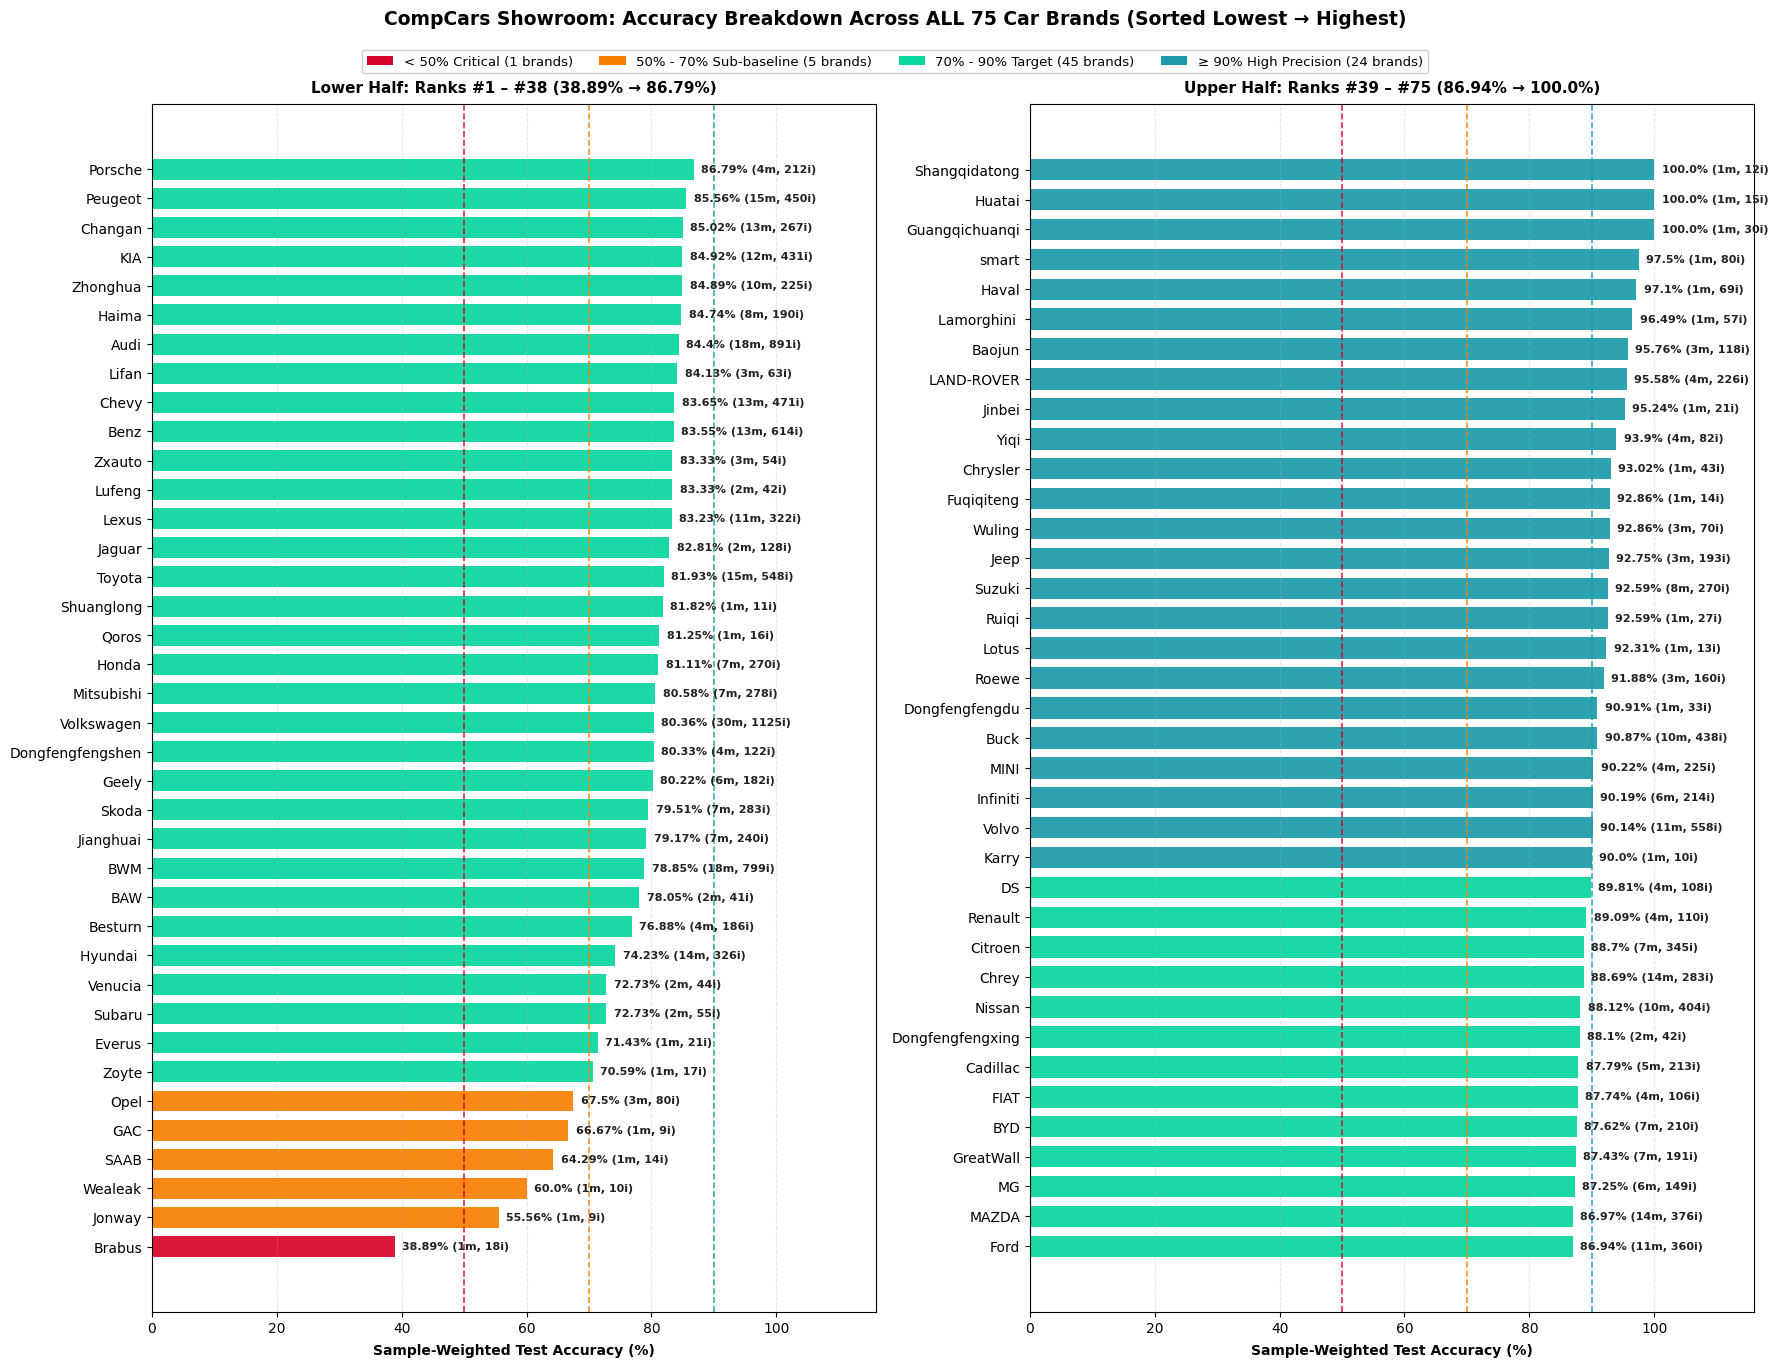

=== Brand Summary: Volkswagen (30 models, 1125 test images, Overall Acc: 80.36%) ===


,model_id,class_name,accuracy_pct,correct_samples,total_samples,folder_path
0,439,Gran Lavida,42.11,8,19,../../../../dataset_Source/image/73/439
1,436,Polo sedan,46.67,7,15,../../../../dataset_Source/image/73/436
2,459,Golf estate,50.00,8,16,../../../../dataset_Source/image/73/459
3,443,Santana,57.14,8,14,../../../../dataset_Source/image/73/443
4,440,Lavide,63.46,33,52,../../../../dataset_Source/image/73/440
5,435,Polo hatchback,64.52,40,62,../../../../dataset_Source/image/73/435
6,504,Magotan,66.67,36,54,../../../../dataset_Source/image/73/504
7,464,Magotan estate,66.67,8,12,../../../../dataset_Source/image/73/464
8,502,Golf GTI,69.44,25,36,../../../../dataset_Source/image/73/502
9,505,Sagitar,70.49,43,61,../../../../dataset_Source/image/73/505


,model_id,class_name,accuracy_pct,correct_samples,total_samples,folder_path
0,439,Gran Lavida,42.11,8,19,../../../../dataset_Source/image/73/439
1,436,Polo sedan,46.67,7,15,../../../../dataset_Source/image/73/436
2,459,Golf estate,50.00,8,16,../../../../dataset_Source/image/73/459
3,443,Santana,57.14,8,14,../../../../dataset_Source/image/73/443
4,440,Lavide,63.46,33,52,../../../../dataset_Source/image/73/440
5,435,Polo hatchback,64.52,40,62,../../../../dataset_Source/image/73/435
6,504,Magotan,66.67,36,54,../../../../dataset_Source/image/73/504
7,464,Magotan estate,66.67,8,12,../../../../dataset_Source/image/73/464
8,502,Golf GTI,69.44,25,36,../../../../dataset_Source/image/73/502
9,505,Sagitar,70.49,43,61,../../../../dataset_Source/image/73/505


In [9]:
# 1. Compute make-wise accuracy across all 75 brands and display tier breakdown
make_acc_df, make_tier_summary = compute_makewise_accuracy(class_acc_df)
print("================ Performance Tier Distribution Across All 75 Brands ================")
display(make_tier_summary)

# 2. Complete ranking table of all 75 brands
print(f"\n================ Complete Ranking Table: All {len(make_acc_df)} Brands (Sorted Lowest → Highest) ================")
pd.set_option('display.max_rows', 85)
display(make_acc_df[["rank", "make_id", "make_name", "num_models", "total_samples", "correct_samples", "accuracy_pct", "macro_acc_pct", "best_model", "worst_model"]])
pd.reset_option('display.max_rows')

# 3. Two-panel visual ranking displaying ALL 75 brands
plot_makewise_accuracy(make_acc_df)

# 4. Interactive Helper: View all models for a specific brand (e.g. Volkswagen)
view_make_summary(class_acc_df, "Volkswagen")


### 9. CompCars CCTV (Surveillance) Overlap Analysis
Analyze how showroom models that overlap with the CompCars CCTV surveillance dataset (`sv_data`) perform compared to showroom-exclusive models.


In [10]:
cctv_merged, low_cctv = analyze_cctv_overlap(class_acc_df, mappings_file="compcars_431_model_mappings.csv")


Total Benchmark Models               : 431
  - Shared with CompCars CCTV        : 181 (Macro Mean Acc: 84.26%)
  - Showroom Only                    : 250 (Macro Mean Acc: 82.15%)

CCTV-Shared Models with < 70% Accuracy : 19 / 181 (10.5%)

Top 10 Lowest Accuracy CCTV-Shared Models:


,model_id,sv_model_id,make_name,class_name,body_type,accuracy_pct,total_samples
223,959,253.0,Hyundai,Mistra,sedan,20.00,10
125,439,72.0,Volkswagen,Gran Lavida,hatchback,42.11,19
113,406,191.0,Changan,Yuexiang V3,sedan,46.15,13
306,1494,241.0,Geely,Ziyoujian,sedan,47.37,19
277,1322,91.0,Toyota,Crown,sedan,48.57,35
58,202,10.0,Buck,Enclave,SUV,57.89,19
207,864,158.0,Nissan,Ma Chi,hatchback,61.90,21
214,915,210.0,Skoda,Haorui,sedan,63.04,46
126,440,71.0,Volkswagen,Lavide,sedan,63.46,52
326,1587,22.0,Lexus,Lexus ES,sedan,64.29,14


### 10. Interactive Filesystem Image Inspection with Bounding Boxes
Inspect real images directly from the dataset folder on disk with official bounding box annotations and viewpoint tags overlaid in a clean grid layout.


In [11]:
# View sample images with bounding boxes for Volkswagen Magotan (model_id: 504)
#view_model_images(class_acc_df, query=504, max_images=8, cols=4, show_bbox=True)
